In [ ]:
import numpy as np
import glob
import os

# Pattern match all DP-GIBO files
dp_files = glob.glob("losses_dp_gibo_d*.npy")

# Build a dict mapping dimension → array
all_losses_dp_gibo = {}
for fp in dp_files:
    # Extract the dimension from the filename, e.g. "losses_dp_gibo_d5.npy" → 5
    basename = os.path.basename(fp)
    d_str = basename.split("_d")[-1].split(".npy")[0]
    d = int(d_str)
    all_losses_dp_gibo[d] = np.load(fp)

# Repeat for random and BO
rand_files = glob.glob("losses_random_d*.npy")
all_losses_random = {
    int(os.path.basename(fp).split("_d")[-1].split(".npy")[0]): np.load(fp)
    for fp in rand_files
}

bo_files = glob.glob("losses_global_BO_d*.npy")
all_losses_global_BO = {
    int(os.path.basename(fp).split("_d")[-1].split(".npy")[0]): np.load(fp)
    for fp in bo_files
}

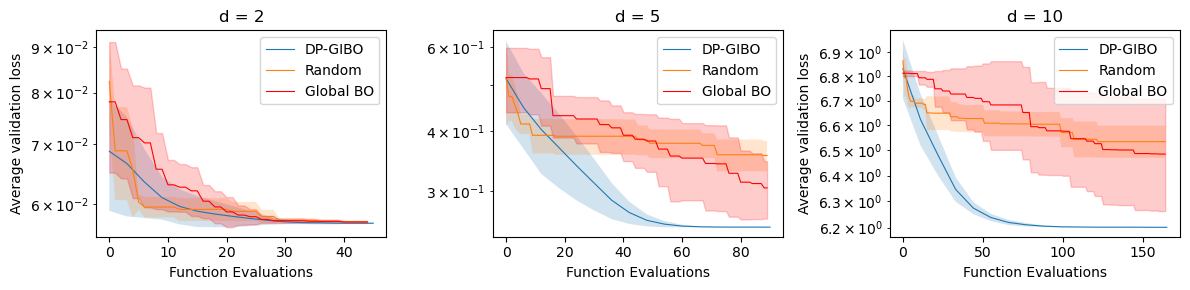

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes = axes.flatten()

num_iterations = 5
path_length = 15

dims = [2, 5, 10]
for ax, d in zip(axes, dims):
    # fetch losses
    losses_dp = all_losses_dp_gibo[d]  # shape (num_iterations, path_length+1)
    losses_rd = all_losses_random[d]  # shape (num_iterations, path_length*(d+1))
    losses_global = all_losses_global_BO[d]

    # compute mean & 95% CI
    mean_dp = losses_dp.mean(axis=0)
    ci_dp = 1.96 * losses_dp.std(axis=0) / np.sqrt(num_iterations)

    mean_rd = losses_rd.mean(axis=0)
    ci_rd = 1.96 * losses_rd.std(axis=0) / np.sqrt(num_iterations)

    mean_global = losses_global.mean(axis=0)
    ci_global = 1.96 * losses_global.std(axis=0) / np.sqrt(num_iterations)

    # x-axes
    bs = d + 1
    random_length = path_length * bs
    x_dp = np.arange(0, random_length + bs, bs)  # 0, bs, 2bs, …, matches len(mean_dp)
    x_rd = np.arange(random_length)  # 0, 1, 2, …, matches len(mean_rd)

    # plot DP-GIBO
    ax.plot(x_dp, mean_dp, label="DP-GIBO", lw=0.8)
    ax.fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2)

    # plot Random
    ax.plot(x_rd, mean_rd, label="Random", lw=0.8)
    ax.fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2)

    # plot Global
    ax.plot(x_rd, mean_global, label="Global BO", lw=0.8, color="red")
    ax.fill_between(
        x_rd, mean_global - ci_global, mean_global + ci_global, alpha=0.2, color="red"
    )

    # styling
    ax.set_yscale("log")
    ax.set_title(f"d = {d}")
    ax.set_xlabel("Function Evaluations")
    if ax in (axes[0], axes[2]):
        ax.set_ylabel("Average validation loss")
    ax.legend(loc="upper right")

plt.tight_layout()

# plt.savefig('May1_attempt4.png')

plt.show()

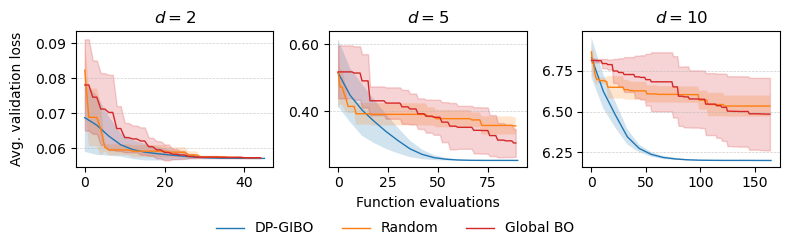

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- assume all_losses_dp_gibo, all_losses_random, all_losses_global_BO exist in scope ---

dims = [2, 5, 10]
num_iterations = 5
path_length = 15

fig, axes = plt.subplots(1, 3, figsize=(8, 2.3), sharey=False)
plt.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.97, wspace=0.3)
axes = axes.flatten()

# Formatter for two decimal places
fmt = FuncFormatter(lambda x, pos: f"{x:.2f}")

for i, (ax, d) in enumerate(zip(axes, dims)):
    # Fetch data arrays
    dp = all_losses_dp_gibo[d]  # shape (num_iterations, path_length+1)
    rd = all_losses_random[d]  # shape (num_iterations, path_length*(d+1))
    glo = all_losses_global_BO[d]  # same shape as rd

    # Compute means & 95% CIs
    mean_dp = dp.mean(axis=0)
    ci_dp = 1.96 * dp.std(axis=0) / np.sqrt(num_iterations)
    mean_rd = rd.mean(axis=0)
    ci_rd = 1.96 * rd.std(axis=0) / np.sqrt(num_iterations)
    mean_glo = glo.mean(axis=0)
    ci_glo = 1.96 * glo.std(axis=0) / np.sqrt(num_iterations)

    # Build x-axes
    bs = d + 1
    rand_len = path_length * bs
    x_dp = np.arange(0, rand_len + bs, bs)
    x_rd = np.arange(rand_len)

    # Plot curves
    ax.plot(x_dp, mean_dp, lw=1, label="DP-GIBO")
    ax.fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2)
    ax.plot(x_rd, mean_rd, lw=1, label="Random")
    ax.fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2)
    ax.plot(x_rd, mean_glo, lw=1, label="Global BO", color="C3")
    ax.fill_between(x_rd, mean_glo - ci_glo, mean_glo + ci_glo, alpha=0.2, color="C3")

    # Styling
    # ax.set_yscale("log")
    ax.set_title(f"$d = {d}$", fontsize=12, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    # Remove spines & ticks
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.tick_params(left=True, bottom=True)

    # Y-tick formatting: fixed two decimals, no scientific notation
    ax.yaxis.set_major_formatter(fmt)

    # X-label only on middle plot
    if i == 1:
        ax.set_xlabel("Function evaluations", fontsize=10, labelpad=4)

# Y-axis label on first panel
axes[0].set_ylabel("Avg. validation loss", fontsize=10, labelpad=8)

# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.1),
)

plt.tight_layout()
# plt.savefig("3dimensions_intro_2.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

In [11]:
# # Repeat for random and BO
# rand_files = glob.glob("losses_random-2*.npy")
# all_losses_random = {int(os.path.basename(fp)):
#                      np.load(fp) for fp in rand_files}

dp_files = glob.glob("losses_dp_gibo.npy")
dp = np.load(dp_files)

TypeError: expected str, bytes or os.PathLike object, not list

In [7]:
all_losses_dp_gibo

{}

In [4]:
losses_dp_gibo = np.load("/Users/jurajmarusic/Desktop/sDPBO/May12_losses_dp_gibo.npy")
losses_random = np.load("/Users/jurajmarusic/Desktop/sDPBO/May12_losses_random.npy")

In [18]:
losses_dp_gibo[0].size

11

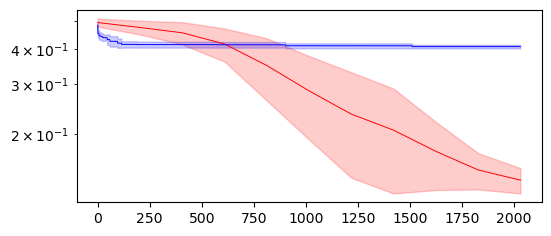

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute mean and confidence intervals
mean_dp_gibo = losses_dp_gibo.mean(axis=0)
std_dp_gibo = losses_dp_gibo.std(axis=0)
ci_dp_gibo = 1.96 * std_dp_gibo / np.sqrt(num_iterations)  # 95% CI

mean_random = losses_random.mean(axis=0)
std_random = losses_random.std(axis=0)
ci_random = 1.96 * std_random / np.sqrt(num_iterations)  # 95% CI

# Plotting
plt.figure(figsize=(6, 2.5))
plt.yscale("log")

bs = 203
path_length = 10
random_length = path_length * bs

# DP-GIBO with confidence intervals (plotted at every 5th point)
x_dp_gibo = np.arange(0, random_length + bs, bs)  # Match the random scale
plt.plot(x_dp_gibo, mean_dp_gibo, label=r"DP-GIBO, $\mu = 1$", color="red", lw=0.7)
plt.fill_between(
    x_dp_gibo,
    mean_dp_gibo - ci_dp_gibo,
    mean_dp_gibo + ci_dp_gibo,
    color="red",
    alpha=0.2,
)

# Random with confidence intervals
x_random = np.arange(random_length)
plt.plot(x_random, mean_random, label="Random", color="blue", lw=0.7)
plt.fill_between(
    x_random, mean_random - ci_random, mean_random + ci_random, color="blue", alpha=0.2
)

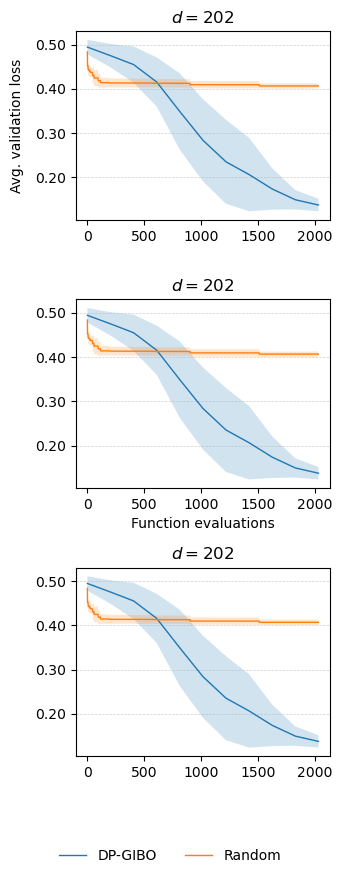

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- assume all_losses_dp_gibo, all_losses_random, all_losses_global_BO exist in scope ---

dims = [202, 202, 202]
num_iterations = 5
path_length = 10

fig, axes = plt.subplots(3, 1, figsize=(3.5, 8), sharey=False)
plt.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.97, wspace=0.3)
axes = axes.flatten()

# Formatter for two decimal places
fmt = FuncFormatter(lambda x, pos: f"{x:.2f}")

for i, (ax, d) in enumerate(zip(axes, dims)):
    # Fetch data arrays
    dp = losses_dp_gibo  # shape (num_iterations, path_length+1)
    rd = losses_random  # shape (num_iterations, path_length*(d+1))
    # glo  = all_losses_global_BO[d]    # same shape as rd

    # Compute means & 95% CIs
    mean_dp = dp.mean(axis=0)
    ci_dp = 1.96 * dp.std(axis=0) / np.sqrt(num_iterations)
    mean_rd = rd.mean(axis=0)
    ci_rd = 1.96 * rd.std(axis=0) / np.sqrt(num_iterations)
    # mean_glo = glo.mean(axis=0)
    # ci_glo   = 1.96 * glo.std(axis=0) / np.sqrt(num_iterations)

    # Build x-axes
    bs = d + 1
    rand_len = path_length * bs
    x_dp = np.arange(0, rand_len + bs, bs)
    x_rd = np.arange(rand_len)

    # Plot curves
    ax.plot(x_dp, mean_dp, lw=1, label="DP-GIBO")
    ax.fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2)
    ax.plot(x_rd, mean_rd, lw=1, label="Random")
    ax.fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2)
    # ax.plot(x_rd, mean_glo,   lw=1, label="Global BO", color="C3")
    # ax.fill_between(x_rd, mean_glo - ci_glo, mean_glo + ci_glo, alpha=0.2, color="C3")

    # Styling
    # ax.set_yscale("log")
    ax.set_title(f"$d = {d}$", fontsize=12, pad=6)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

    # Remove spines & ticks
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.tick_params(left=True, bottom=True)

    # Y-tick formatting: fixed two decimals, no scientific notation
    ax.yaxis.set_major_formatter(fmt)

    # X-label only on middle plot
    if i == 1:
        ax.set_xlabel("Function evaluations", fontsize=10, labelpad=4)

# Y-axis label on first panel
axes[0].set_ylabel("Avg. validation loss", fontsize=10, labelpad=8)

# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.1),
)

plt.tight_layout()
# plt.savefig("3dimensions_intro_2.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

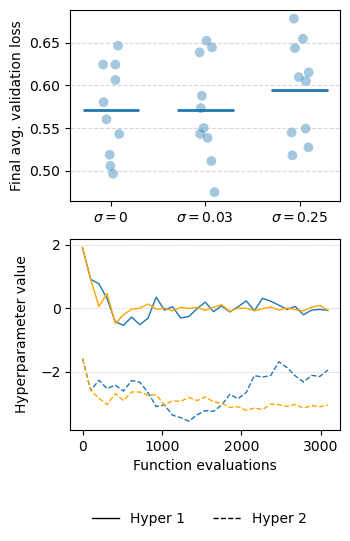

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

num_iterations = 5
path_length = 10
d = 103

import pickle

with open("all_losses_003.pkl", "rb") as f:
    trythisgibo = pickle.load(f)

data = trythisgibo

sigmas = [0.00, 0.03, 0.25]
fig, axes = plt.subplots(2, 1, figsize=(3, 6), sharey=False)
plt.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.97, wspace=0.3)
axes = axes.flatten()

for i, (σ, c) in enumerate(zip(sigmas, colors)):
    finals = data[σ][20:30, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    axes[0].scatter(
        x_base + jitter, finals, color="#1f77b4", alpha=0.4, s=50, edgecolors="none"
    )

    # mean line
    m = finals.mean()
    axes[0].hlines(m, i - 0.3, i + 0.3, color="#1f77b4", lw=2)

# cosmetics
axes[0].set_xticks(range(len(sigmas)))
axes[0].set_xticklabels([str(s) for s in sigmas])
axes[0].set_xticklabels([rf"$\sigma={s:g}$" for s in sigmas])
# axes[0].set_xlabel('σ')
axes[0].set_ylabel("Final avg. validation loss")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)


# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.05),
)

axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

axes[1].set_ylabel("Hyperparameter value", fontsize=10, labelpad=8)

path_dp1 = np.load(f"dp-path1.npy")
path_nondp1 = np.load(f"nondp-path1.npy")

path_dp2 = np.load(f"dp-path2.npy")
path_nondp2 = np.load(f"nondp-path2.npy")

bs = d
rand_len = 30 * bs
x_dp = np.arange(0, rand_len + bs, bs)

axes[1].plot(x_dp, path_dp1, lw=1, label="Hyper 1", color="#1f77b4")
axes[1].plot(x_dp, path_nondp1, lw=1, label="Hyper 1", color="orange")

axes[1].plot(x_dp, path_dp2, linestyle="--", lw=1, label="Hyper 2", color="#1f77b4")
axes[1].plot(x_dp, path_nondp2, linestyle="--", lw=1, label="Hyper 2", color="orange")

axes[1].set_xlabel("Function evaluations", fontsize=10, labelpad=4)

from matplotlib.lines import Line2D

# 2) a second legend just for the linestyles
style_proxies = [
    Line2D([0], [0], color="black", lw=1, linestyle="-", label="Hyper 1"),
    Line2D([0], [0], color="black", lw=1, linestyle="--", label="Hyper 2"),
]
leg2 = fig.legend(
    style_proxies,
    ["Hyper 1", "Hyper 2"],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.00),
)  # tweak the y-offset as needed

# plt.tight_layout()
plt.savefig("SVM_plot.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

In [ ]:
import pickle

with open("all_losses_003.pkl", "rb") as f:
    trythisgibo = pickle.load(f)

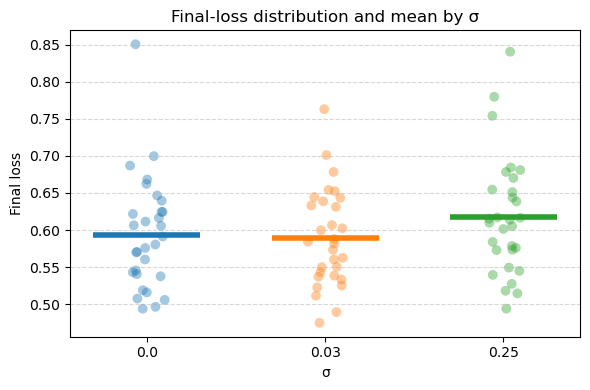

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- your data dict: σ → array(shape=[n_runs, n_steps])
data = trythisgibo

sigmas = [0.0, 0.03, 0.25]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # blue, orange, green

fig, ax = plt.subplots(figsize=(6, 4))

for i, (σ, c) in enumerate(zip(sigmas, colors)):
    finals = data[σ][:30, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    ax.scatter(x_base + jitter, finals, color=c, alpha=0.4, s=50, edgecolors="none")

    # mean line
    m = finals.mean()
    ax.hlines(m, i - 0.3, i + 0.3, color=c, lw=4)

# cosmetics
ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([str(s) for s in sigmas])
ax.set_xlabel("σ")
ax.set_ylabel("Final loss")
ax.set_title("Final‐loss distribution and mean by σ")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_batches_dp_gibo_varyingepsilons_50reps.pkl",
    "rb",
) as f:
    data2 = pickle.load(f)

In [127]:
data2

{0.5: array([[25., 24., 23., ...,  9.,  9.,  5.],
        [25., 24., 23., ...,  9.,  7.,  8.],
        [25., 24., 22., ...,  6.,  8.,  6.],
        ...,
        [25., 24., 21., ...,  7.,  3.,  5.],
        [25., 24., 23., ...,  9.,  6.,  6.],
        [25., 24., 22., ...,  9.,  5.,  6.]]),
 2.0: array([[15., 15., 14., ...,  3.,  2.,  4.],
        [15., 15., 14., ...,  4.,  2.,  4.],
        [15., 15., 14., ...,  5.,  2.,  4.],
        ...,
        [15., 15., 13., ...,  5.,  3.,  4.],
        [15., 15., 14., ...,  5.,  4.,  3.],
        [15., 15., 14., ...,  3.,  3.,  3.]]),
 7.5: array([[9., 8., 7., ..., 1., 1., 1.],
        [9., 8., 7., ..., 1., 2., 2.],
        [9., 8., 7., ..., 1., 1., 1.],
        ...,
        [9., 8., 6., ..., 1., 2., 1.],
        [9., 8., 7., ..., 1., 1., 2.],
        [9., 8., 8., ..., 1., 2., 1.]])}

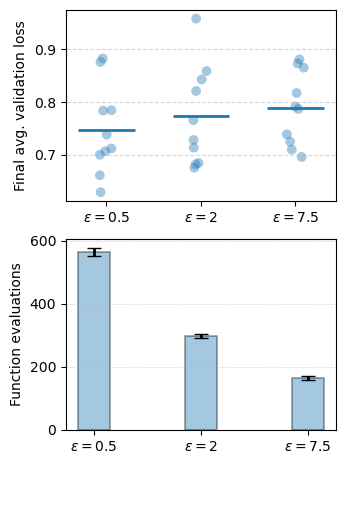

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import pickle

with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingepsilons_50reps.pkl",
    "rb",
) as f:
    data1 = pickle.load(f)

epsilons = [0.5, 2.0, 7.5]
fig, axes = plt.subplots(2, 1, figsize=(3, 6), sharey=False)
plt.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.97, wspace=0.3)
axes = axes.flatten()

for i, (epsilon, c) in enumerate(zip(epsilons, colors)):
    finals = data1[epsilon][20:30, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    axes[0].scatter(
        x_base + jitter, finals, color="#1f77b4", alpha=0.4, s=50, edgecolors="none"
    )

    # mean line
    m = finals.mean()
    axes[0].hlines(m, i - 0.3, i + 0.3, color="#1f77b4", lw=2)

# cosmetics
axes[0].set_xticks(range(len(epsilons)))
axes[0].set_xticklabels([str(s) for s in epsilons])
axes[0].set_xticklabels([rf"$\varepsilon={s:g}$" for s in epsilons])
# axes[0].set_xlabel('σ')
axes[0].set_ylabel("Final avg. validation loss")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)


# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.05),
)

axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# Second subplot: bar + CI
means, ci_h = [], []
for ε in epsilons:
    # sum over steps 20:30 for each run
    finals = data2[ε][20:30, :].sum(axis=1)
    m = finals.mean()
    se = stats.sem(finals)
    h = se * stats.t.ppf(0.975, len(finals) - 1)
    means.append(m)
    ci_h.append(h)

x = np.arange(len(epsilons))
bars = axes[1].bar(
    x,
    means,
    yerr=ci_h,
    capsize=5,  # cap width
    width=0.3,
    alpha=0.4,
    color="#1f77b4",
    edgecolor="black",
    linewidth=1.2,
    error_kw=dict(elinewidth=2, ecolor="black"),
)


# cosmetics
axes[1].set_xticks(range(len(epsilons)))

axes[1].set_xticklabels([rf"$\varepsilon={s:g}$" for s in epsilons])
axes[1].set_ylabel("Function evaluations")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

# plt.tight_layout()
plt.savefig("SVM_plot.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

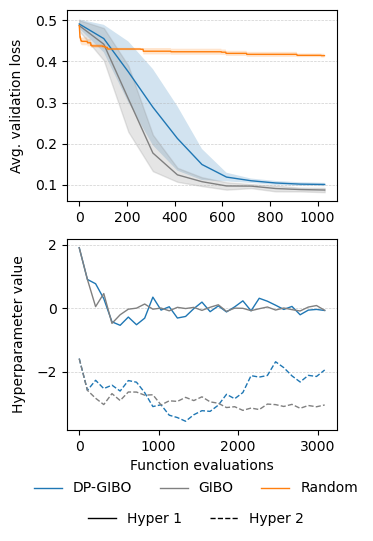

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

losses_dp_gibo = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo_15May.npy")
losses_dp_gibo2 = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo2_15May.npy")
losses_random = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_random_15May.npy")

num_iterations = 5
path_length = 10
d = 103

fig, axes = plt.subplots(2, 1, figsize=(3, 6), sharey=False)
plt.subplots_adjust(top=0.88, bottom=0.18, left=0.07, right=0.97, wspace=0.3)
axes = axes.flatten()

dp = losses_dp_gibo
dp2 = losses_dp_gibo2
rd = losses_random

# Compute means & 95% CIs
mean_dp = dp.mean(axis=0)
ci_dp = 1.96 * dp.std(axis=0) / np.sqrt(num_iterations)
mean_dp2 = dp2.mean(axis=0)
ci_dp2 = 1.96 * dp2.std(axis=0) / np.sqrt(num_iterations)
mean_rd = rd.mean(axis=0)
ci_rd = 1.96 * rd.std(axis=0) / np.sqrt(num_iterations)

# Build x-axes
bs = d
rand_len = path_length * bs
x_dp = np.arange(0, rand_len + bs, bs)
x_rd = np.arange(rand_len)

# Plot curves
axes[0].plot(x_dp, mean_dp, lw=1, label="DP-GIBO")
axes[0].fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2)

axes[0].plot(x_dp, mean_dp2, lw=1, label="GIBO", color="gray")
axes[0].fill_between(
    x_dp, mean_dp2 - ci_dp2, mean_dp2 + ci_dp2, alpha=0.2, color="gray"
)

axes[0].plot(x_rd, mean_rd, lw=1, label="Random")
axes[0].fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2)

# axes[0].set_title(f"$d = {d}$", fontsize=12, pad=6)
axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

axes[0].set_ylabel("Avg. validation loss", fontsize=10, labelpad=8)

# Shared legend below
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.05),
)

axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

axes[1].set_ylabel("Hyperparameter value", fontsize=10, labelpad=8)

path_dp1 = np.load(f"dp-path1.npy")
path_nondp1 = np.load(f"nondp-path1.npy")

path_dp2 = np.load(f"dp-path2.npy")
path_nondp2 = np.load(f"nondp-path2.npy")

bs = d
rand_len = 30 * bs
x_dp = np.arange(0, rand_len + bs, bs)

axes[1].plot(x_dp, path_dp1, lw=1, label="Hyper 1", color="#1f77b4")
axes[1].plot(x_dp, path_nondp1, lw=1, label="Hyper 1", color="gray")

axes[1].plot(x_dp, path_dp2, linestyle="--", lw=1, label="Hyper 2", color="#1f77b4")
axes[1].plot(x_dp, path_nondp2, linestyle="--", lw=1, label="Hyper 2", color="gray")

axes[1].set_xlabel("Function evaluations", fontsize=10, labelpad=4)

from matplotlib.lines import Line2D

# 2) a second legend just for the linestyles
style_proxies = [
    Line2D([0], [0], color="black", lw=1, linestyle="-", label="Hyper 1"),
    Line2D([0], [0], color="black", lw=1, linestyle="--", label="Hyper 2"),
]
leg2 = fig.legend(
    style_proxies,
    ["Hyper 1", "Hyper 2"],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.00),
)  # tweak the y-offset as needed

# plt.tight_layout()
# plt.savefig("SVM_plot.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

In [ ]:
with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingepsilons_10reps_four2.pkl",
    "rb",
) as f:
    data1 = pickle.load(f)

In [27]:
data1

{0.3: array([[0.68678331, 0.63658249, 0.58713257, 0.58888292, 0.59811646,
         0.60117668, 0.60144418, 0.60277933, 0.58981735, 0.57715875,
         0.55893749, 0.56789607, 0.5495857 , 0.55139929, 0.55533326,
         0.55832946, 0.5511412 , 0.54287112, 0.53795779, 0.52681243,
         0.51585495, 0.51336563, 0.52036148, 0.51715797, 0.51600641,
         0.51057327],
        [0.73100114, 0.58493966, 0.54721123, 0.53966582, 0.55033928,
         0.53038299, 0.52312797, 0.52557528, 0.5132457 , 0.51445991,
         0.51306289, 0.50367463, 0.48985535, 0.49920514, 0.49251646,
         0.50896537, 0.50243759, 0.48898831, 0.48151916, 0.47628409,
         0.46923122, 0.46680748, 0.46935564, 0.46356526, 0.46312508,
         0.45948079],
        [0.90661728, 0.71797174, 0.70619589, 0.66947281, 0.64476019,
         0.62719393, 0.61339194, 0.61890203, 0.58302689, 0.5625782 ,
         0.55561012, 0.54419762, 0.54784167, 0.5370388 , 0.52728879,
         0.51148432, 0.51024812, 0.50003242, 0.4918026

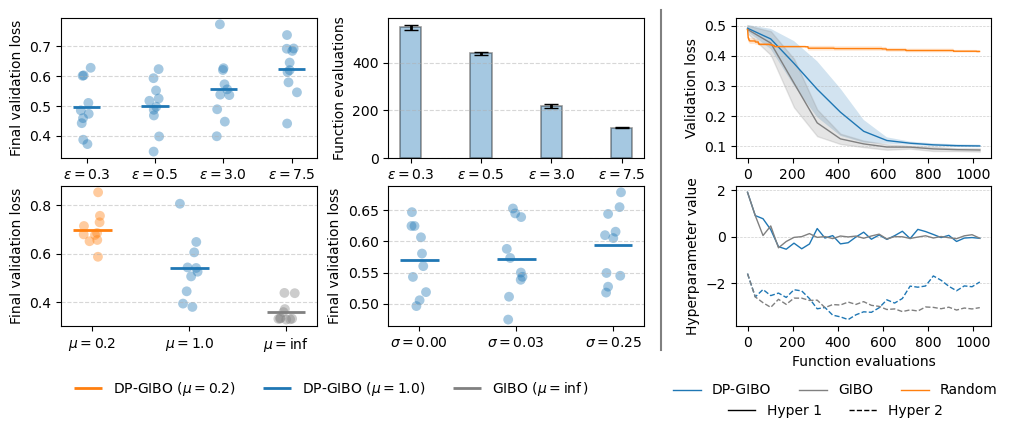

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy import stats

colors = ["#ff7f0e", "#1f77b4", "gray", "gray"]

# … load your data, define epsilons, colors, etc. …

fig = plt.figure(figsize=(12, 4))

# create a 2×4 grid, but make column 2 very narrow (it'll be our gutter)
gs = GridSpec(
    nrows=2,
    ncols=4,
    figure=fig,
    width_ratios=[1, 1, -0.2, 1],  # <-- gutter at col index=2
    wspace=0.4,  # space *between* all columns
    hspace=0.2,  # vertical space
)

# assign your six axes, skipping the gutter column
axes = [
    fig.add_subplot(gs[0, 0]),  # top-left
    fig.add_subplot(gs[0, 1]),  # top-middle
    fig.add_subplot(gs[0, 3]),  # top-right (skip col=2)
    fig.add_subplot(gs[1, 0]),  # bottom-left
    fig.add_subplot(gs[1, 1]),  # bottom-middle
    fig.add_subplot(gs[1, 3]),  # bottom-right
]

# finally, draw a divider line over that gutter column
# we know column 2 spans from left= sum(width_ratios[:2]) / total to left+width_ratios[2]/total
total = sum([1, 1, -0.2, 1])
left_edge = (0.55 + 1) / total  # fraction of figure width
right_edge = left_edge + 0.2 / total
y0, y1 = 0.05, 0.9  # inset from bottom/top in figure coords

fig.add_artist(
    Line2D(
        [right_edge, right_edge],
        [y0, y1],
        transform=fig.transFigure,
        color="gray",
        linewidth=1.5,
    )
)

# TOP LEFT
import pickle

with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingepsilons_10reps_four2.pkl",
    "rb",
) as f:
    data1 = pickle.load(f)
epsilons = [0.3, 0.5, 3.0, 7.5]
for i, (epsilon, c) in enumerate(zip(epsilons, colors)):
    finals = data1[epsilon][:, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    axes[0].scatter(
        x_base + jitter, finals, color="#1f77b4", alpha=0.4, s=50, edgecolors="none"
    )

    # mean line
    m = finals.mean()
    axes[0].hlines(m, i - 0.2, i + 0.2, color="#1f77b4", lw=2)

# cosmetics
axes[0].set_xticks(range(len(epsilons)))
axes[0].set_xticklabels([rf"$\varepsilon={ε:.1f}$" for ε in epsilons])
axes[0].set_ylabel("Final validation loss")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)

################

# TOP MIDDLE

means, ci_h = [], []
with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_batches_dp_gibo_varyingepsilons_10reps_four2.pkl",
    "rb",
) as f:
    data2 = pickle.load(f)
for ε in epsilons:
    # sum over steps 20:30 for each run
    finals = data2[ε][:, :].sum(axis=1)
    m = finals.mean()
    se = stats.sem(finals)
    h = se * stats.t.ppf(0.975, len(finals) - 1)
    means.append(m)
    ci_h.append(h)

x = np.arange(len(epsilons))
bars = axes[1].bar(
    x,
    means,
    yerr=ci_h,
    capsize=5,  # cap width
    width=0.3,
    alpha=0.4,
    color="#1f77b4",
    edgecolor="black",
    linewidth=1.2,
    error_kw=dict(elinewidth=2, ecolor="black"),
)


# cosmetics
axes[1].set_xticks(range(len(epsilons)))
axes[1].set_xticklabels([rf"$\varepsilon={ε:.1f}$" for ε in epsilons])
axes[1].set_ylabel("Function evaluations")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)

###########

# TOP RIGHT

losses_dp_gibo = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo_15May.npy")
losses_dp_gibo2 = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo2_15May.npy")
losses_random = np.load("/Users/jurajmarusic/Desktop/sDPBO/losses_random_15May.npy")

num_iterations = 5
path_length = 10
d = 103


dp = losses_dp_gibo
dp2 = losses_dp_gibo2
rd = losses_random

# Compute means & 95% CIs
mean_dp = dp.mean(axis=0)
ci_dp = 1.96 * dp.std(axis=0) / np.sqrt(num_iterations)
mean_dp2 = dp2.mean(axis=0)
ci_dp2 = 1.96 * dp2.std(axis=0) / np.sqrt(num_iterations)
mean_rd = rd.mean(axis=0)
ci_rd = 1.96 * rd.std(axis=0) / np.sqrt(num_iterations)

# Build x-axes
bs = d
rand_len = path_length * bs
x_dp = np.arange(0, rand_len + bs, bs)
x_rd = np.arange(rand_len)

# Plot curves
axes[2].plot(x_dp, mean_dp, lw=1, label="DP-GIBO")
axes[2].fill_between(x_dp, mean_dp - ci_dp, mean_dp + ci_dp, alpha=0.2)

axes[2].plot(x_dp, mean_dp2, lw=1, label="GIBO", color="gray")
axes[2].fill_between(
    x_dp, mean_dp2 - ci_dp2, mean_dp2 + ci_dp2, alpha=0.2, color="gray"
)

axes[2].plot(x_rd, mean_rd, lw=1, label="Random")
axes[2].fill_between(x_rd, mean_rd - ci_rd, mean_rd + ci_rd, alpha=0.2)

# axes[0].set_title(f"$d = {d}$", fontsize=12, pad=6)
axes[2].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

axes[2].set_ylabel("Validation loss", fontsize=10)

#########


####BOTTOM LEFT

with open(
    "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingmus.pkl", "rb"
) as f:
    data3 = pickle.load(f)
mus = [0.2, 1.0, 10000.0]
mus_plot = ["0.2", "1.0", rf"\inf"]
mu_labels = [
    rf"DP-GIBO ($\mu = 0.2$)",
    rf"DP-GIBO ($\mu = 1.0$)",
    rf"GIBO ($\mu = \inf$)",
]

for i, (mu, c) in enumerate(zip(mus, colors)):
    finals = data3[mu][:, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    axes[3].scatter(
        x_base + jitter, finals, color=c, alpha=0.4, s=50, edgecolors="none"
    )

    # mean line
    m = finals.mean()
    axes[3].hlines(m, i - 0.2, i + 0.2, color=c, lw=2, label=mu_labels[i])

# cosmetics
axes[3].set_xticks(range(len(mus)))
axes[3].set_xticklabels([rf"$\mu={s}$" for s in mus_plot])
axes[3].set_ylabel("Final validation loss")
axes[3].grid(axis="y", linestyle="--", alpha=0.5)

########

### BOTTOM MIDDLE

import pickle

with open("all_losses_003.pkl", "rb") as f:
    trythisgibo = pickle.load(f)

data = trythisgibo

sigmas = [0.00, 0.03, 0.25]

for i, (σ, c) in enumerate(zip(sigmas, colors)):
    finals = data[σ][20:30, -1]  # shape (n_runs,)
    x_base = np.full_like(finals, i)

    # scatter with jitter
    jitter = (np.random.rand(len(finals)) - 0.5) * 0.2
    axes[4].scatter(
        x_base + jitter, finals, color="#1f77b4", alpha=0.4, s=50, edgecolors="none"
    )

    # mean line
    m = finals.mean()
    axes[4].hlines(m, i - 0.2, i + 0.2, color="#1f77b4", lw=2)

# cosmetics
axes[4].set_xticks(range(len(sigmas)))
axes[4].set_xticklabels([rf"$\sigma={s:.2f}$" for s in sigmas])
axes[4].set_ylabel("Final validation loss")
axes[4].grid(axis="y", linestyle="--", alpha=0.5)


##### BOTTOM RIGHT

axes[5].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

axes[5].set_ylabel("Hyperparameter value", fontsize=10)

path_dp1 = np.load(f"dp-path1.npy")
path_nondp1 = np.load(f"nondp-path1.npy")

path_dp2 = np.load(f"dp-path2.npy")
path_nondp2 = np.load(f"nondp-path2.npy")

bs = d / 3
rand_len = 30 * bs
x_dp = np.arange(0, rand_len + bs, bs)

axes[5].plot(x_dp, path_dp1, lw=1, label="Hyper 1", color="#1f77b4")
axes[5].plot(x_dp, path_nondp1, lw=1, label="Hyper 1", color="gray")

axes[5].plot(x_dp, path_dp2, linestyle="--", lw=1, label="Hyper 2", color="#1f77b4")
axes[5].plot(x_dp, path_nondp2, linestyle="--", lw=1, label="Hyper 2", color="gray")

axes[5].set_xlabel("Function evaluations", fontsize=10)

from matplotlib.lines import Line2D

###### LEGEND #######

# Shared legend below
handles, labels = axes[2].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.77, -0.1),
)

style_proxies = [
    Line2D([0], [0], color="black", lw=1, linestyle="-", label="Hyper 1"),
    Line2D([0], [0], color="black", lw=1, linestyle="--", label="Hyper 2"),
]
leg2 = fig.legend(
    style_proxies,
    ["Hyper 1", "Hyper 2"],
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.77, -0.15),
)  # tweak the y-offset as needed

# Shared legend below
handles, labels = axes[3].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.35, -0.1),
)

plt.savefig("Main_plot.png", bbox_inches="tight", pad_inches=0.1)
plt.show()

/var/folders/6t/jd2xs54s1pv8b3360_5xg19h0000gn/T/ipykernel_33127/2768268447.py:257: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.03, 0.20, 0.995, 0.985])


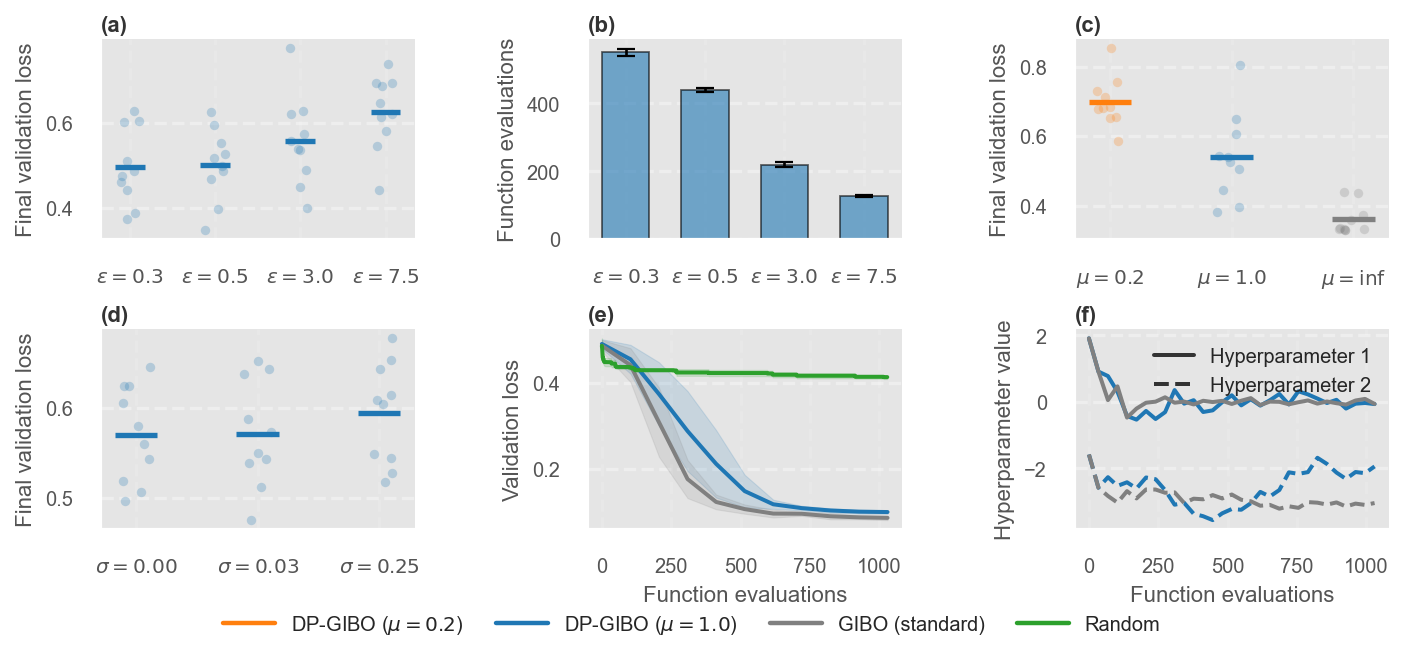

In [14]:
# === Main figure with unified 4-entry legend + style key in last panel ========
# Order (by CONTENT) requested: a, b, d, e, c, f
# Final LABELS (standard): top row -> (a),(b),(c); bottom row -> (d),(e),(f)

import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats
from matplotlib.lines import Line2D

# ----------------------------- Paths & constants -----------------------------
PATH_EPS_LOSS = "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingepsilons_10reps_four2.pkl"
PATH_EPS_BATCH = "/Users/jurajmarusic/Desktop/sDPBO/all_batches_dp_gibo_varyingepsilons_10reps_four2.pkl"
PATH_LOSS_DP1 = "/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo_15May.npy"
PATH_LOSS_DP2 = "/Users/jurajmarusic/Desktop/sDPBO/losses_dp_gibo2_15May.npy"
PATH_LOSS_RAND = "/Users/jurajmarusic/Desktop/sDPBO/losses_random_15May.npy"
PATH_MU_LOSS = "/Users/jurajmarusic/Desktop/sDPBO/all_losses_dp_gibo_varyingmus.pkl"
PATH_SIGMA_LOSS = "all_losses_003.pkl"
PATH_HYP_DP1 = "dp-path1.npy"
PATH_HYP_NDP1 = "nondp-path1.npy"
PATH_HYP_DP2 = "dp-path2.npy"
PATH_HYP_NDP2 = "nondp-path2.npy"

epsilons = [0.3, 0.5, 3.0, 7.5]
mus = [0.2, 1.0, 10000.0]  # 10000 ~ ∞ proxy
mus_plot = ["0.2", "1.0", r"\inf"]
sigmas = [0.00, 0.03, 0.25]

# ------------------------------ Color mapping --------------------------------
COL = {
    "dp02": "#ff7f0e",  # DP-GIBO (μ=0.2) ORANGE
    "dp10": "#1f77b4",  # DP-GIBO (μ=1.0) BLUE
    "gibo": "gray",  # GIBO GRAY
    "rand": "#2ca02c",  # RANDOM GREEN
    "text": "#333333",
}

# ------------------------------- Figure style --------------------------------
plt.rcParams.update(
    {
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "grid.linestyle": "--",
        "grid.alpha": 0.35,
        "savefig.dpi": 300,
        "figure.dpi": 160,
    }
)

fig = plt.figure(figsize=(8.8, 3.9))  # full width for 2-column
# Leave extra bottom room for a single shared legend (no overlap with axes text)
fig.subplots_adjust(left=0.08, right=0.995, top=0.985, bottom=0.20)

gs = GridSpec(nrows=2, ncols=3, figure=fig, wspace=0.55, hspace=0.45)
axes = [fig.add_subplot(gs[i, j]) for i in range(2) for j in range(3)]
# axes indices: 0=TL, 1=TM, 2=TR, 3=BL, 4=BM, 5=BR


def panel_label(ax, label):
    ax.text(
        0.0,
        1.02,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=COL["text"],
    )


def scatter_with_mean(ax, values, xpos, width=0.35, color=None):
    """Low-alpha jittered dots + prominent mean line."""
    vals = np.asarray(values)
    jitter = (np.random.rand(len(vals)) - 0.5) * (width * 0.7)
    ax.scatter(
        np.full_like(vals, xpos, dtype=float) + jitter,
        vals,
        s=18,
        alpha=0.25,
        linewidths=0,
        color=color,
    )
    m = vals.mean()
    ax.hlines(m, xpos - width / 2, xpos + width / 2, lw=2.4, color=color)
    return m


def tidy_axes(ax):
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", alpha=0.12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def mean_ci(arr):
    m = arr.mean(axis=0)
    ci = 1.96 * arr.std(axis=0) / np.sqrt(arr.shape[0])
    return m, ci


# ============================= CONTENT PANELS ================================
# CONTENT a: ε vs loss  -> place at TL (axes[0]) and label as (a)
ax = axes[0]
with open(PATH_EPS_LOSS, "rb") as f:
    data_eps_loss = pickle.load(f)
for i, eps in enumerate(epsilons):
    finals = data_eps_loss[eps][:, -1]
    scatter_with_mean(ax, finals, i, color=COL["dp10"])  # DP μ=1.0 color
ax.set_xticks(range(len(epsilons)))
ax.set_xticklabels([rf"$\varepsilon={e:.1f}$" for e in epsilons])
ax.set_ylabel("Final validation loss")
panel_label(ax, "(a)")
tidy_axes(ax)

# CONTENT b: ε vs function evals -> place at TM (axes[1]) and label as (b)
ax = axes[1]
with open(PATH_EPS_BATCH, "rb") as f:
    data_eps_batches = pickle.load(f)
means, ci = [], []
for eps in epsilons:
    vals = data_eps_batches[eps][:, :].sum(axis=1)
    m = vals.mean()
    se = stats.sem(vals)
    h = se * stats.t.ppf(0.975, len(vals) - 1)
    means.append(m)
    ci.append(h)
x = np.arange(len(epsilons))
ax.bar(
    x,
    means,
    yerr=ci,
    capsize=4,
    width=0.6,
    alpha=0.6,
    edgecolor="black",
    linewidth=0.8,
    color=COL["dp10"],
    error_kw=dict(elinewidth=1.2, ecolor="black"),
)
ax.set_xticks(range(len(epsilons)))
ax.set_xticklabels([rf"$\varepsilon={e:.1f}$" for e in epsilons])
ax.set_ylabel("Function evaluations")
panel_label(ax, "(b)")
tidy_axes(ax)

# CONTENT d: μ vs loss -> place at TR (axes[2]) but label as (c)
ax = axes[2]
with open(PATH_MU_LOSS, "rb") as f:
    data_mu_loss = pickle.load(f)
mu_colors = [COL["dp02"], COL["dp10"], COL["gibo"]]  # 0.2, 1.0, ∞
for i, (mu, col) in enumerate(zip(mus, mu_colors)):
    finals = data_mu_loss[mu][:, -1]
    scatter_with_mean(ax, finals, i, color=col)
ax.set_xticks(range(len(mus)))
ax.set_xticklabels([rf"$\mu={s}$" for s in mus_plot])
ax.set_ylabel("Final validation loss")
panel_label(ax, "(c)")
tidy_axes(ax)

# CONTENT e: σ vs loss -> place at BL (axes[3]) and label as (d)
ax = axes[3]
with open(PATH_SIGMA_LOSS, "rb") as f:
    data_sigma = pickle.load(f)
for i, s in enumerate(sigmas):
    finals = data_sigma[s][20:30, -1]
    scatter_with_mean(ax, finals, i, color=COL["dp10"])  # DP μ=1.0 color
ax.set_xticks(range(len(sigmas)))
ax.set_xticklabels([rf"$\sigma={s:.2f}$" for s in sigmas])
ax.set_ylabel("Final validation loss")
panel_label(ax, "(d)")
tidy_axes(ax)

# CONTENT c: Convergence curves -> place at BM (axes[4]) and label as (e)
ax = axes[4]
dp = np.load(PATH_LOSS_DP1)  # DP-GIBO
dp2 = np.load(PATH_LOSS_DP2)  # GIBO
rand = np.load(PATH_LOSS_RAND)  # Random
m1, c1 = mean_ci(dp)
m2, c2 = mean_ci(dp2)
m3, c3 = mean_ci(rand)
bs = 103
x1 = np.arange(m1.shape[0]) * bs
x2 = np.arange(m2.shape[0]) * bs
x3 = np.arange(m3.shape[0])
ax.plot(x1, m1, lw=1.8, label="DP-GIBO (μ = 1.0)", color=COL["dp10"])
ax.fill_between(x1, m1 - c1, m1 + c1, alpha=0.15, color=COL["dp10"])
ax.plot(x2, m2, lw=1.8, label="GIBO (standard)", color=COL["gibo"])
ax.fill_between(x2, m2 - c2, m2 + c2, alpha=0.15, color=COL["gibo"])
ax.plot(x3, m3, lw=1.8, label="Random", color=COL["rand"])
ax.fill_between(x3, m3 - c3, m3 + c3, alpha=0.15, color=COL["rand"])
ax.set_ylabel("Validation loss")
ax.set_xlabel("Function evaluations")
panel_label(ax, "(e)")
tidy_axes(ax)

# CONTENT f: Hyperparameter paths -> place at BR (axes[5]) and label as (f)
ax = axes[5]
path_dp1 = np.load(PATH_HYP_DP1)  # Hyper 1 (DP)
path_ndp1 = np.load(PATH_HYP_NDP1)  # Hyper 1 (non-DP)
path_dp2 = np.load(PATH_HYP_DP2)  # Hyper 2 (DP)
path_ndp2 = np.load(PATH_HYP_NDP2)  # Hyper 2 (non-DP)
bs_h = 103 / 3


def plot_series(ax, y, ls="-", color=None):
    x = bs_h * np.arange(len(y))
    ax.plot(x, y, lw=1.8, linestyle=ls, color=color)


# Hyper 1 = solid; Hyper 2 = dashed
plot_series(ax, path_dp1, ls="-", color=COL["dp10"])  # DP BLUE
plot_series(ax, path_ndp1, ls="-", color=COL["gibo"])  # GIBO GRAY
plot_series(ax, path_dp2, ls="--", color=COL["dp10"])  # DP BLUE dashed
plot_series(ax, path_ndp2, ls="--", color=COL["gibo"])  # GIBO GRAY dashed
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Hyperparameter value")
panel_label(ax, "(f)")
tidy_axes(ax)
# In-panel style legend for line types
style_handles = [
    Line2D(
        [0], [0], color=COL["text"], lw=1.8, linestyle="-", label="Hyperparameter 1"
    ),
    Line2D(
        [0], [0], color=COL["text"], lw=1.8, linestyle="--", label="Hyperparameter 2"
    ),
]
ax.legend(handles=style_handles, loc="upper right", frameon=False)

# ----------------------------- Single shared legend --------------------------
# Only these four entries, shared across the figure:
shared_handles = [
    Line2D([0], [0], color=COL["dp02"], lw=2.0, label=r"DP-GIBO ($\mu=0.2$)"),
    Line2D([0], [0], color=COL["dp10"], lw=2.0, label=r"DP-GIBO ($\mu=1.0$)"),
    Line2D([0], [0], color=COL["gibo"], lw=2.0, label=r"GIBO (standard)"),
    Line2D([0], [0], color=COL["rand"], lw=2.0, label=r"Random"),
]
fig.legend(
    shared_handles,
    [h.get_label() for h in shared_handles],
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    frameon=False,
    handlelength=2.6,
    columnspacing=1.6,
)

# Final layout (keeps bottom legends clear)
plt.tight_layout(rect=[0.03, 0.20, 0.995, 0.985])

# Save
# plt.savefig("Main_plot_reordered.pdf", bbox_inches="tight")
plt.savefig("Two_experiments_plot.png", bbox_inches="tight", dpi=300)
plt.show()